In [3]:
# Setup: imports, seeds, and a parameterizable CartPole wrapper
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque
from typing import Callable

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Configurable Environment Wrapper ---
class ParameterizedCartPole(gym.Wrapper):
    def __init__(self, env, gravity=9.8, masscart=1.0):
        super().__init__(env)
        self.gravity = gravity
        self.masscart = masscart

    def reset(self, **kwargs):
        # Inject physics parameters into the Gym env (CartPole implementation exposes these on unwrapped)
        try:
            self.env.unwrapped.gravity = self.gravity
            self.env.unwrapped.masscart = self.masscart
        except Exception:
            # Some Gym versions may not expose these attributes; ignore if not available
            pass
        return self.env.reset(**kwargs)

def make_env(gravity: float = 9.8, mass: float = 1.0):
    env = gym.make("CartPole-v1")
    return ParameterizedCartPole(env, gravity=gravity, masscart=mass)

# Utility: simple plotting helper
def plot_rewards(rewards, label="Rewards", smooth=5):
    sm = np.convolve(rewards, np.ones(smooth) / smooth, mode='valid')
    plt.plot(sm, label=label)
    plt.xlabel('Episode (smoothed)')
    plt.ylabel('Return')
    plt.legend()
    plt.grid(True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
import gym
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    def forward(self, x):
        return self.net(x)

class Agent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.q_net = DQN(state_dim, action_dim)
        self.target_net = DQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.gamma = gamma
        self.memory = deque(maxlen=10000)
        self.batch_size = 64
        self.action_dim = action_dim
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.05
        self.loss_fn = nn.MSELoss()

    def act(self, state, train=True):
        if train and np.random.rand() < self.epsilon:
            return np.random.randint(self.action_dim)
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_vals = self.q_net(state_t)
        return int(q_vals.argmax().item())

    def remember(self, s, a, r, ns, d):
        self.memory.append((s, a, r, ns, d))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return
        batch = random.sample(self.memory, self.batch_size)
        s, a, r, ns, d = zip(*batch)
        s = torch.FloatTensor(s)
        a = torch.LongTensor(a).unsqueeze(1)
        r = torch.FloatTensor(r).unsqueeze(1)
        ns = torch.FloatTensor(ns)
        d = torch.FloatTensor(d).unsqueeze(1)

        with torch.no_grad():
            q_next = self.target_net(ns).max(1, keepdim=True)[0]
            target = r + (1 - d) * self.gamma * q_next

        q_curr = self.q_net(s).gather(1, a)
        loss = self.loss_fn(q_curr, target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

# --- Training Loop Helper ---
def train_agent(env_maker: Callable[[], gym.Env], episodes=200, label="Agent", randomize=False):
    env = env_maker()
    agent = Agent(env.observation_space.shape[0], env.action_space.n)
    rewards = []

    for ep in range(episodes):
        # Domain Randomization (if enabled)
        if randomize:
            g = np.random.uniform(5.0, 15.0)
            env = make_env(gravity=g)

        reset_out = env.reset()
        # gym/gymnasium compatibility: reset may return (obs, info)
        state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        total_r = 0
        done = False
        while not done:
            action = agent.act(state)
            next_out = env.step(action)
            next_state = next_out[0] if isinstance(next_out[0], np.ndarray) or True else next_out[0]
            reward = next_out[1]
            terminated = next_out[2]
            truncated = next_out[3] if len(next_out) > 3 else False
            done = terminated or truncated

            agent.remember(state, action, reward, next_state, done)
            agent.train_step()
            state = next_state
            total_r += reward

        if ep % 10 == 0:
            agent.update_target()
        rewards.append(total_r)

    return agent, rewards

In [5]:
!pip install gymnasium

## Part 1 — The Generalization Gap & Domain Randomization ✅

We'll train two agents:
- **Baseline:** trained on Earth gravity (9.8).
- **Randomized:** trained with domain randomization (gravity drawn from [5, 15]).

We'll evaluate both on a **target** high-gravity domain (e.g., 25.0) to demonstrate transfer.

Training Baseline on Source (Gravity=9.8)...


/Users/tahamajs/Documents/uni/DRL/.venv/lib/python3.13/site-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/var/folders/cg/l2rdx46d6lv3b5xc17b420yc0000gn/T/ipykernel_45682/2623674476.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  s = torch.FloatTensor(s)


Training Randomized Agent (Gravity=5.0 to 15.0)...

--- Zero-Shot Transfer Results (Target Gravity=25.0) ---
Baseline Agent Score:   206.10 (Likely Failed)
Randomized Agent Score: 287.10 (Better Generalization)


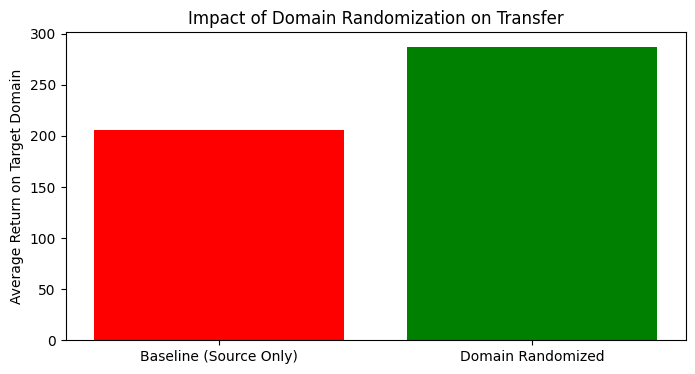

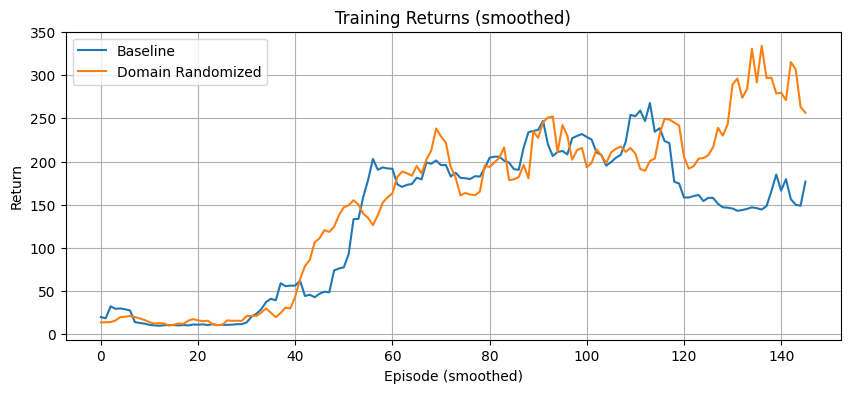

In [6]:
# Train Baseline and Randomized agents (short runs for example purposes)
print("Training Baseline on Source (Gravity=9.8)...")
source_agent, src_rewards = train_agent(lambda: make_env(gravity=9.8), episodes=150)

print("Training Randomized Agent (Gravity=5.0 to 15.0)...")
rand_agent, rand_rewards = train_agent(lambda: make_env(gravity=9.8), episodes=150, randomize=True)

# Evaluate function
def evaluate(agent: Agent, gravity: float, episodes: int = 10):
    env = make_env(gravity=gravity)
    scores = []
    for _ in range(episodes):
        reset_out = env.reset()
        s = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        score = 0
        done = False
        while not done:
            a = agent.act(s, train=False)
            next_out = env.step(a)
            s = next_out[0]
            r = next_out[1]
            term = next_out[2]
            trunc = next_out[3] if len(next_out) > 3 else False
            done = term or trunc
            score += r
        scores.append(score)
    return np.mean(scores)

# Evaluate on a strong gravity target (25.0)
score_baseline = evaluate(source_agent, gravity=25.0)
score_random = evaluate(rand_agent, gravity=25.0)

print(f"\n--- Zero-Shot Transfer Results (Target Gravity=25.0) ---")
print(f"Baseline Agent Score:   {score_baseline:.2f} (Likely Failed)")
print(f"Randomized Agent Score: {score_random:.2f} (Better Generalization)")

plt.figure(figsize=(8,4))
plt.bar(["Baseline (Source Only)", "Domain Randomized"], [score_baseline, score_random], color=['red', 'green'])
plt.ylabel("Average Return on Target Domain")
plt.title("Impact of Domain Randomization on Transfer")
plt.show()

# Plot training curves (smoothed)
plt.figure(figsize=(10,4))
plot_rewards(src_rewards, label='Baseline')
plot_rewards(rand_rewards, label='Domain Randomized')
plt.title('Training Returns (smoothed)')
plt.show()

## Part 2 — Dynamics Adaptation (Sim-to-Real) 🔧

We'll collect random transitions from both the simulator (source) and a high-gravity target (serving as "real"), train a discriminator to distinguish them, then use the discriminator's log-odds as a reward offset while re-training on the simulator.

In [8]:
# --- Discriminator & Data Collection ---
class DynamicsDiscriminator(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        # Input: state + action + next_state
        self.net = nn.Sequential(
            nn.Linear(state_dim * 2 + 1, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, s, a, ns):
        cat = torch.cat([s, a, ns], dim=1)
        return self.net(cat)


def collect_transitions(env, episodes=20):
    data = []
    reset_out = env.reset()
    state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
    for _ in range(episodes):
        done = False
        while not done:
            action = env.action_space.sample()  # Random policy for data collection
            next_out = env.step(action)
            next_state = next_out[0]
            terminated = next_out[2]
            truncated = next_out[3] if len(next_out) > 3 else False
            done = terminated or truncated
            data.append((state, action, next_state))
            state = next_state
            if done:
                reset_out = env.reset()
                state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
    return data

print("Collecting Dynamics Data...")
source_data = collect_transitions(make_env(gravity=9.8), episodes=50)   # Simulator
target_data = collect_transitions(make_env(gravity=25.0), episodes=50)  # "Real World"

# Sanity
print(f"Collected {len(source_data)} source and {len(target_data)} target transitions.")

# Train Discriminator
discriminator = DynamicsDiscriminator(state_dim=4, action_dim=1)
opt_d = optim.Adam(discriminator.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

print("Training Dynamics Discriminator...")
for epoch in range(500):
    # Sample batches
    src_batch = random.sample(source_data, 32)
    tgt_batch = random.sample(target_data, 32)

    def prepare(batch):
        s, a, ns = zip(*batch)
        s = torch.FloatTensor(s)
        a = torch.FloatTensor(a).unsqueeze(1)
        ns = torch.FloatTensor(ns)
        return s, a, ns

    s_s, a_s, ns_s = prepare(src_batch)
    s_t, a_t, ns_t = prepare(tgt_batch)

    pred_src = discriminator(s_s, a_s, ns_s)
    pred_tgt = discriminator(s_t, a_t, ns_t)

    loss = loss_fn(pred_src, torch.zeros_like(pred_src)) + loss_fn(pred_tgt, torch.ones_like(pred_tgt))

    opt_d.zero_grad()
    loss.backward()
    opt_d.step()

    if epoch % 100 == 0:
        with torch.no_grad():
            acc_src = ((pred_src < 0.5).float().mean().item())
            acc_tgt = ((pred_tgt > 0.5).float().mean().item())
        print(f"Epoch {epoch:03d}  loss={loss.item():.4f}  acc_src={acc_src:.2f}  acc_tgt={acc_tgt:.2f}")

Collected 1266 source and 1001 target transitions.
Training Dynamics Discriminator...
Epoch 000  loss=1.4001  acc_src=0.34  acc_tgt=0.47
Epoch 100  loss=1.3743  acc_src=0.56  acc_tgt=0.62
Epoch 200  loss=1.4184  acc_src=0.62  acc_tgt=0.34
Epoch 300  loss=1.3322  acc_src=0.72  acc_tgt=0.47
Epoch 400  loss=1.4056  acc_src=0.72  acc_tgt=0.25


Retraining with Adapted Rewards...
Adapted Agent Score: 116.40


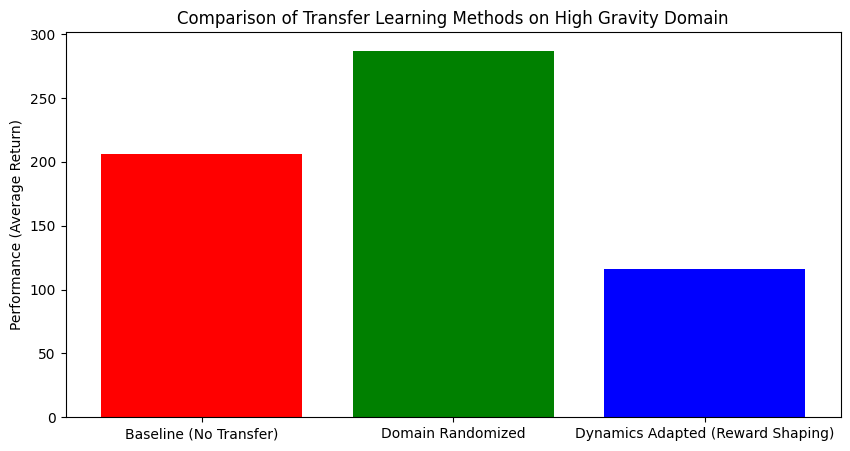

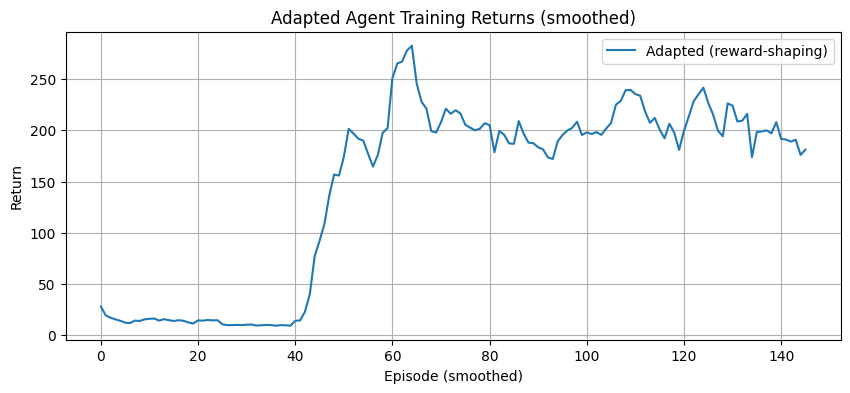

In [9]:
# --- Retrain Agent on Source with Reward Offset ---
print("Retraining with Adapted Rewards...")
adapted_agent = Agent(4, 2)
env = make_env(gravity=9.8)
adapted_rewards = []

for ep in range(150):
    reset_out = env.reset()
    state = reset_out[0] if isinstance(reset_out, tuple) else reset_out
    total_r = 0
    done = False
    while not done:
        action = adapted_agent.act(state)
        next_out = env.step(action)
        next_state = next_out[0]
        reward = next_out[1]
        terminated = next_out[2]
        truncated = next_out[3] if len(next_out) > 3 else False
        done = terminated or truncated

        # --- CALCULATE REWARD OFFSET ---
        with torch.no_grad():
            s_t = torch.FloatTensor(state).unsqueeze(0)
            a_t = torch.FloatTensor([action]).unsqueeze(1)
            ns_t = torch.FloatTensor(next_state).unsqueeze(0)

            prob_target = discriminator(s_t, a_t, ns_t).item()
            prob_target = np.clip(prob_target, 0.01, 0.99)
            delta_r = np.log(prob_target / (1 - prob_target))
            modified_reward = reward + 0.1 * delta_r  # scale down to keep stable

        adapted_agent.remember(state, action, modified_reward, next_state, done)
        adapted_agent.train_step()
        state = next_state
        total_r += reward  # logging original reward for clarity

    if ep % 10 == 0:
        adapted_agent.update_target()
    adapted_rewards.append(total_r)

# Evaluate adapted agent on target domain
score_adapted = evaluate(adapted_agent, gravity=25.0)
print(f"Adapted Agent Score: {score_adapted:.2f}")

# Final Comparison Plot
plt.figure(figsize=(10, 5))
plt.bar(
    ["Baseline (No Transfer)", "Domain Randomized", "Dynamics Adapted (Reward Shaping)"],
    [score_baseline, score_random, score_adapted],
    color=['red', 'green', 'blue']
)
plt.title("Comparison of Transfer Learning Methods on High Gravity Domain")
plt.ylabel("Performance (Average Return)")
plt.show()

# Plot adapted training curve to inspect learning
plt.figure(figsize=(10,4))
plot_rewards(adapted_rewards, label='Adapted (reward-shaping)')
plt.title('Adapted Agent Training Returns (smoothed)')
plt.show()

### Lecture 27 — Key Concepts & Takeaways 🧠

**What is transfer learning in RL?**
- Transfer learning uses knowledge from a *source* MDP to improve learning or performance in a *target* MDP.

**Where can knowledge be stored?**
- **Q-function**: indicates good actions or states; can be reused or fine-tuned.
- **Policy**: maps observations to actions; often needs adaptation.
- **Model/Dynamics**: learned dynamics (f(s,a) -> s') can be reused for planning or adaptation.
- **Features / Representations**: hidden state embeddings that make downstream adaptation easier.

**Types of transfer**
1. **Forward transfer (sequential)** — train on a source then apply to target.
2. **Multi-task** — learn shared representations across several tasks simultaneously.
3. **Meta-learning** — learn to learn; enables fast adaptation (few-shot) on new tasks.

**Transfer by "shot"**
- **0-shot**: apply policy as-is (no adaptation). 0-shot is sensitive to domain shift.
- **1-shot / Few-shot**: allow a small number of adaptation trials in the target.

**Challenges**
- **Domain shift**: p_s(x) != p_t(x) or dynamics differ (p_s(s'|s,a) != p_t(s'|s,a)).
- **Over-specialization**: policies may become deterministic and lose exploration for fine-tuning.
- **Simulator shortcuts**: policies exploiting simulator artifacts may fail in real world.

**Domain adaptation for dynamics (Reward offset)**
- The reward-correction idea: r~(s,a) = r(s,a) + Δr(s,a) where
  Δr(s,a,s') ≈ log p_t(s'|s,a) − log p_s(s'|s,a)
- Using a domain classifier D(s,a,s') that predicts target vs source, one can use log-odds:
  Δr ≈ log( D / (1 − D) ) (clipped & scaled for stability)

---

### Practical Strategies
- **Domain randomization**: randomize simulation parameters during training to improve 0-shot transfer.
- **Policy regularization during fine-tuning**: keep the policy close to the pretrained one to avoid catastrophic shifts.
- **Adversarial domain adaptation**: encourage domain-invariant features using a domain classifier with gradient reversal.


Evaluating transfer shots:
0-shot score:  223.30
1-shot score:  203.80
few-shot score: 111.90


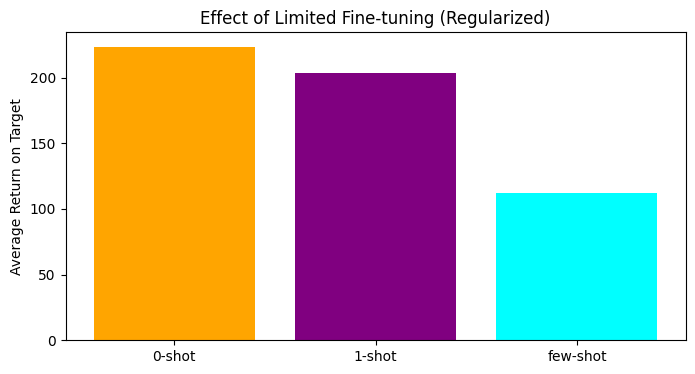

In [10]:
# --- Fine-tuning experiments (1-shot, few-shot) ---

def train_step_with_reg(agent: Agent, snapshot: dict, lambda_reg: float = 0.0):
    """Single gradient step using a minibatch with optional L2 proximity regularization to `snapshot`."""
    if len(agent.memory) < agent.batch_size:
        return
    batch = random.sample(agent.memory, agent.batch_size)
    s, a, r, ns, d = zip(*batch)
    s = torch.FloatTensor(s)
    a = torch.LongTensor(a).unsqueeze(1)
    r = torch.FloatTensor(r).unsqueeze(1)
    ns = torch.FloatTensor(ns)
    d = torch.FloatTensor(d).unsqueeze(1)

    with torch.no_grad():
        q_next = agent.target_net(ns).max(1, keepdim=True)[0]
        target = r + (1 - d) * agent.gamma * q_next

    q_curr = agent.q_net(s).gather(1, a)
    loss = agent.loss_fn(q_curr, target)

    # Proximity regularizer (L2 on parameters)
    if lambda_reg > 0.0 and snapshot is not None:
        prox = 0.0
        for (name, p) in agent.q_net.named_parameters():
            prox = prox + torch.sum((p - snapshot[name].to(p.device)) ** 2)
        loss = loss + lambda_reg * prox

    agent.optimizer.zero_grad()
    loss.backward()
    agent.optimizer.step()


def fine_tune_and_evaluate(pretrained_agent: Agent, env_maker: Callable[[], gym.Env], adapt_episodes=1, lambda_reg=0.0):
    """Copy the agent, do limited adaptation on the target, and evaluate post-adaptation."""
    # shallow copy weights
    agent = Agent(4, 2)
    agent.q_net.load_state_dict(pretrained_agent.q_net.state_dict())
    agent.target_net.load_state_dict(pretrained_agent.target_net.state_dict())
    agent.memory = deque(list(pretrained_agent.memory), maxlen=pretrained_agent.memory.maxlen)

    # snapshot for regularization
    snapshot = {name: p.detach().clone() for name, p in agent.q_net.named_parameters()}

    env = env_maker()
    # limited adaptation
    for ep in range(adapt_episodes):
        reset_out = env.reset()
        s = reset_out[0] if isinstance(reset_out, tuple) else reset_out
        done = False
        while not done:
            a = agent.act(s)
            next_out = env.step(a)
            ns = next_out[0]
            r = next_out[1]
            term = next_out[2]
            trunc = next_out[3] if len(next_out) > 3 else False
            done = term or trunc
            agent.remember(s, a, r, ns, done)
            # take a few gradient steps per collected transition
            for _ in range(3):
                train_step_with_reg(agent, snapshot, lambda_reg)
            s = ns
    # Evaluate
    score = evaluate(agent, gravity=25.0, episodes=10)
    return score

# Run 0-shot, 1-shot, and few-shot tests
print("Evaluating transfer shots:")
score_0shot = evaluate(source_agent, gravity=25.0)
score_1shot = fine_tune_and_evaluate(source_agent, lambda: make_env(gravity=25.0), adapt_episodes=1, lambda_reg=1e-4)
score_fewshot = fine_tune_and_evaluate(source_agent, lambda: make_env(gravity=25.0), adapt_episodes=20, lambda_reg=1e-4)

print(f"0-shot score:  {score_0shot:.2f}")
print(f"1-shot score:  {score_1shot:.2f}")
print(f"few-shot score: {score_fewshot:.2f}")

plt.figure(figsize=(8,4))
plt.bar(["0-shot","1-shot","few-shot"], [score_0shot, score_1shot, score_fewshot], color=['orange','purple','cyan'])
plt.ylabel('Average Return on Target')
plt.title('Effect of Limited Fine-tuning (Regularized)')
plt.show()

In [11]:
# --- Adversarial Domain Adaptation (skeleton) ---
# Gradient Reversal Layer (simple implementation)
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambd=1.0):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambd, None

class FeatureExtractor(nn.Module):
    def __init__(self, state_dim=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
    def forward(self, x):
        return self.net(x)

class DomainClassifier(nn.Module):
    def __init__(self, feat_dim=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(feat_dim,32), nn.ReLU(), nn.Linear(32,1), nn.Sigmoid())
    def forward(self, x):
        return self.net(x)

# Example of one adversarial update step (skeleton)
feat = FeatureExtractor()
d_class = DomainClassifier()
opt_feat = optim.Adam(feat.parameters(), lr=1e-3)
opt_dom = optim.Adam(d_class.parameters(), lr=1e-3)

# Gather a minibatch of transitions from source and target
batch_s = random.sample(source_data, 32)
batch_t = random.sample(target_data, 32)

s_s, a_s, ns_s = zip(*batch_s)
s_t, a_t, ns_t = zip(*batch_t)

s_s = torch.FloatTensor(s_s)
s_t = torch.FloatTensor(s_t)

# Domain labels: 0=source, 1=target
dom_s = torch.zeros((s_s.size(0),1))
dom_t = torch.ones((s_t.size(0),1))

# Forward pass through feature extractor
z_s = feat(s_s)
z_t = feat(s_t)

# Update domain classifier (standard)
pred_s = d_class(z_s.detach())
pred_t = d_class(z_t.detach())
loss_dom = nn.BCELoss()(pred_s, dom_s) + nn.BCELoss()(pred_t, dom_t)
opt_dom.zero_grad(); loss_dom.backward(); opt_dom.step()

# Update feature extractor to confuse domain classifier using GradReverse
z_s_rev = GradReverse.apply(z_s, 1.0)
z_t_rev = GradReverse.apply(z_t, 1.0)
pred_s2 = d_class(z_s_rev)
pred_t2 = d_class(z_t_rev)
loss_feat = nn.BCELoss()(pred_s2, dom_t) + nn.BCELoss()(pred_t2, dom_s)
opt_feat.zero_grad(); loss_feat.backward(); opt_feat.step()

print("Performed one adversarial adaptation step (skeleton). Use this approach to encourage domain-invariant features.")

Performed one adversarial adaptation step (skeleton). Use this approach to encourage domain-invariant features.


### End Notes & Practical Advice ✅

- Use **domain randomization** as a strong baseline for 0-shot transfer. It's simple and effective.
- Use **regularized fine-tuning** when limited target data is available (1- or few-shot).
- When possible, use **adversarial adaptation** or feature matching to learn representations that are invariant to domain shifts.
- Always clip and scale reward offsets (log-odds) — they can destabilize learning if used raw.



In [13]:
src_agent_smoke, _ = train_agent(lambda: make_env(gravity=9.8), episodes=30)
rand_agent_smoke, _ = train_agent(lambda: make_env(gravity=9.8), episodes=30, randomize=True)

score_baseline_smoke = evaluate(src_agent_smoke, gravity=25.0, episodes=5)
score_rand_smoke = evaluate(rand_agent_smoke, gravity=25.0, episodes=5)
print(f"Smoke: Baseline on 25g: {score_baseline_smoke:.2f} | Randomized on 25g: {score_rand_smoke:.2f}")

# Collect small dynamics dataset
s_data = collect_transitions(make_env(gravity=9.8), episodes=10)
t_data = collect_transitions(make_env(gravity=25.0), episodes=10)
print(f"Smoke: Collected {len(s_data)} src and {len(t_data)} tgt transitions")

# Quick discriminator training (fewer epochs)
disc_smoke = DynamicsDiscriminator(4,1)
optd = optim.Adam(disc_smoke.parameters(), lr=1e-3)
lossf = nn.BCELoss()
for epoch in range(100):
    sb = random.sample(s_data, min(32, len(s_data)))
    tb = random.sample(t_data, min(32, len(t_data)))
    def prep(b):
        s,a,ns = zip(*b)
        return torch.FloatTensor(s), torch.FloatTensor(a).unsqueeze(1), torch.FloatTensor(ns)
    s_s,a_s,ns_s = prep(sb)
    s_t,a_t,ns_t = prep(tb)
    p_s = disc_smoke(s_s,a_s,ns_s)
    p_t = disc_smoke(s_t,a_t,ns_t)
    loss = lossf(p_s, torch.zeros_like(p_s)) + lossf(p_t, torch.ones_like(p_t))
    optd.zero_grad(); loss.backward(); optd.step()

print("Smoke: Discriminator quick trained")

# Retrain small adapted agent
a_smoke = Agent(4,2)
env_smoke = make_env(gravity=9.8)
for ep in range(30):
    reset_out = env_smoke.reset()
    s = reset_out[0] if isinstance(reset_out, tuple) else reset_out
    done=False
    while not done:
        a = a_smoke.act(s)
        next_out = env_smoke.step(a)
        ns = next_out[0]
        r = next_out[1]
        term = next_out[2]
        trunc = next_out[3] if len(next_out) > 3 else False
        done = term or trunc
        with torch.no_grad():
            s_t = torch.FloatTensor(s).unsqueeze(0)
            a_t = torch.FloatTensor([a]).unsqueeze(1)
            ns_t = torch.FloatTensor(ns).unsqueeze(0)
            prob = disc_smoke(s_t,a_t,ns_t).item()
            prob = np.clip(prob, 0.01, 0.99)
            delta = np.log(prob/(1-prob))
            mod_r = r + 0.1 * delta
        a_smoke.remember(s,a,mod_r,ns,done)
        a_smoke.train_step()
        s = ns
    if ep % 10 == 0: a_smoke.update_target()

score_adapt_smoke = evaluate(a_smoke, gravity=25.0, episodes=5)
print(f"Smoke: Adapted agent on 25g: {score_adapt_smoke:.2f}")

# Quick fine-tune shot check
score_0 = evaluate(src_agent_smoke, gravity=25.0, episodes=5)
score_1 = fine_tune_and_evaluate(src_agent_smoke, lambda: make_env(gravity=25.0), adapt_episodes=1, lambda_reg=1e-4)
score_f = fine_tune_and_evaluate(src_agent_smoke, lambda: make_env(gravity=25.0), adapt_episodes=5, lambda_reg=1e-4)
print(f"Smoke: 0-shot {score_0:.2f}, 1-shot {score_1:.2f}, few-shot {score_f:.2f}")

print("Smoke test completed.")

Smoke: Baseline on 25g: 23.60 | Randomized on 25g: 33.40
Smoke: Collected 169 src and 238 tgt transitions
Smoke: Discriminator quick trained
Smoke: Adapted agent on 25g: 104.80
Smoke: 0-shot 20.20, 1-shot 10.50, few-shot 10.80
Smoke test completed.
